# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2020\PSI20_01NI\01_Transmission\LE"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"H:\700 Campaigns - internal\780 2020\PSI20_01NI\temp\exps_LE\IMAT_LE_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2020\PSI20_01NI\02_CS_results"

In [5]:
flight_path = 56

## Remove Casing 
read the directory and extract values from images

In [6]:
casing_dict = read_saved_dict (src_dir, proc_folder = ['05_p3'])
stack_dict = read_saved_dict (src_dir, proc_folder = ['01_p1'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  1.62it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in casing_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 10, end_slice = 15)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_05_p3  = [[225, 165, 204, 48]]

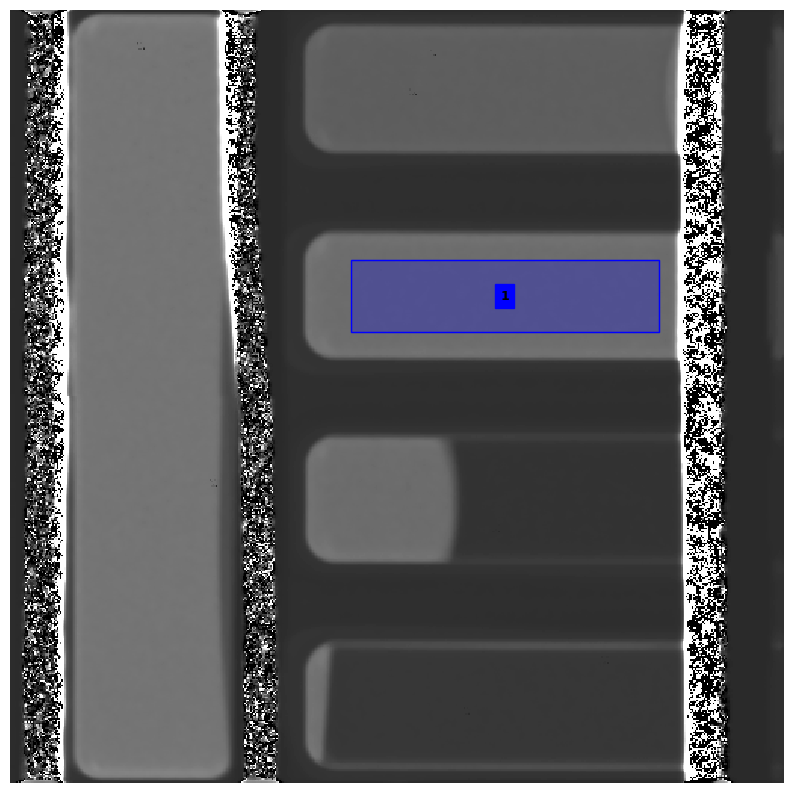

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_05_p3, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in casing_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [11]:
val_casing = get_roi_values (casing_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = flight_path, start_slice = 1, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
val_casing

,Wavelength [Å],Values_acq_0
0,3.330655,0.859753
1,3.610227,0.874099
2,3.880330,0.875277
3,4.144383,0.885326
4,4.400715,0.897646
5,4.650974,0.918307
6,4.899270,0.914744
7,5.152621,0.912036
8,5.399826,0.906480
9,5.641791,0.904341


## Process a single  experiment

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [13]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_01_p1  = [[229, 437, 196, 49]] #PE
#ROIs_01_p1  = [[317, 301, 111, 49]] #H20

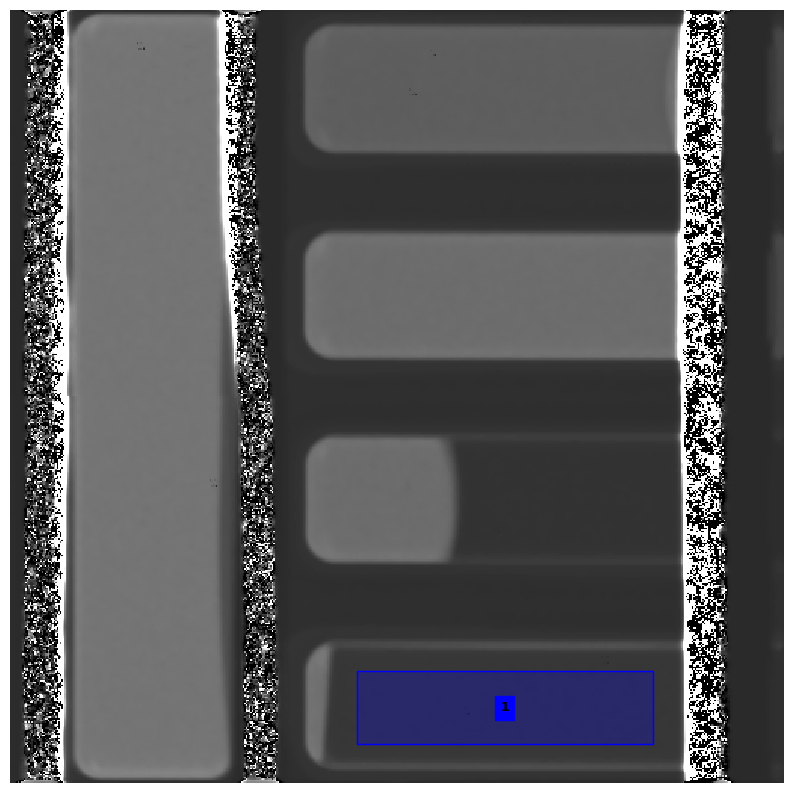

In [14]:
show_img(avg_imgs[0], dr = [(ROIs_01_p1, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [15]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [16]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = flight_path, start_slice = 1, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [17]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,Values_acq_9
0,3.330655,0.141016,0.132369,0.128809,0.120471,0.147514,0.144285,0.147071,0.142387,0.126056,0.127044
1,3.610227,0.333480,0.328445,0.332338,0.331519,0.330142,0.331293,0.333154,0.332487,0.328404,0.329137
2,3.880330,0.322661,0.320464,0.321451,0.321308,0.321114,0.322009,0.321704,0.321792,0.321330,0.320475
3,4.144383,0.315502,0.313483,0.315073,0.315680,0.314950,0.314551,0.315092,0.314498,0.313821,0.313384
4,4.400715,0.310000,0.306923,0.308887,0.308213,0.308976,0.308626,0.308456,0.307845,0.308060,0.308409
5,4.650974,0.305148,0.303335,0.304707,0.304990,0.304290,0.305313,0.304773,0.305120,0.304992,0.304749
6,4.899270,0.294874,0.291786,0.294117,0.293390,0.293389,0.294101,0.293892,0.293605,0.293581,0.294078
7,5.152621,0.283031,0.281802,0.283183,0.283391,0.282535,0.282796,0.282747,0.284052,0.282338,0.282075
8,5.399826,0.275841,0.270212,0.272386,0.272000,0.272644,0.272507,0.272035,0.272019,0.271956,0.272214
9,5.641791,0.263907,0.261292,0.261314,0.262709,0.262636,0.262343,0.263789,0.262169,0.262612,0.262398


### Remove the casing


In [18]:
trans_rois = divide_DF (val_rois, val_casing)

In [19]:
trans_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,Values_acq_9
0,3.330655,0.164019,0.153962,0.149821,0.140123,0.171578,0.167821,0.171062,0.165614,0.146619,0.147769
1,3.610227,0.381513,0.375752,0.380207,0.379269,0.377694,0.379011,0.381140,0.380376,0.375705,0.376544
2,3.880330,0.368639,0.366129,0.367257,0.367094,0.366872,0.367894,0.367545,0.367646,0.367118,0.366142
3,4.144383,0.356368,0.354087,0.355884,0.356570,0.355745,0.355294,0.355906,0.355234,0.354470,0.353976
4,4.400715,0.345348,0.341920,0.344108,0.343356,0.344207,0.343817,0.343628,0.342947,0.343186,0.343576
5,4.650974,0.332294,0.330320,0.331814,0.332122,0.331360,0.332474,0.331886,0.332264,0.332124,0.331859
6,4.899270,0.322357,0.318982,0.321530,0.320735,0.320733,0.321512,0.321284,0.320969,0.320943,0.321487
7,5.152621,0.310329,0.308981,0.310495,0.310723,0.309785,0.310071,0.310017,0.311449,0.309569,0.309281
8,5.399826,0.304299,0.298089,0.300487,0.300062,0.300772,0.300621,0.300101,0.300083,0.300013,0.300299
9,5.641791,0.291822,0.288931,0.288955,0.290498,0.290417,0.290093,0.291692,0.289901,0.290390,0.290154


### H cross section parameters

In [20]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.2}

## exp1000 -> LP30


In [21]:
compounds_dict = [pe,pe,pe,pe,pe,pe,pe,pe,pe,pe]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [24]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (trans_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = True, 
                               name_xlsx = 'test_LE.xlsx')

In [23]:
cs_table

,Wavelength [Å],CS_H_in_PE_Values_acq_0,CS_H_in_PE_Values_acq_1,CS_H_in_PE_Values_acq_2,CS_H_in_PE_Values_acq_3,CS_H_in_PE_Values_acq_4,CS_H_in_PE_Values_acq_5,CS_H_in_PE_Values_acq_6,CS_H_in_PE_Values_acq_7,CS_H_in_PE_Values_acq_8,CS_H_in_PE_Values_acq_9
0,3.330655,111.704981,115.710030,117.435831,121.671346,108.853494,110.254624,109.044108,111.092453,118.803176,118.308779
1,3.610227,58.216265,59.179215,58.433296,58.589552,58.852930,58.632604,58.278155,58.405065,59.187111,59.045909
2,3.880330,60.327414,60.759792,60.565224,60.593318,60.631548,60.455498,60.515470,60.498066,60.589032,60.757599
3,4.144383,62.406380,62.812772,62.492401,62.370567,62.517230,62.597506,62.488605,62.608180,62.744405,62.832741
4,4.400715,64.329677,64.961030,64.557203,64.695651,64.539064,64.610814,64.645634,64.771228,64.727067,64.655259
5,4.650974,66.701868,67.079021,66.793494,66.734637,66.880159,66.667717,66.779748,66.707706,66.734291,66.784795
6,4.899270,68.555141,69.221461,68.717863,68.874509,68.874789,68.721437,68.766295,68.828305,68.833398,68.726327
7,5.152621,70.889668,71.165201,70.855829,70.809297,71.000803,70.942393,70.953390,70.661755,71.044817,71.103824
8,5.399826,72.058719,73.363681,72.856602,72.946264,72.796560,72.828490,72.938054,72.941912,72.956507,72.896370
9,5.641791,74.635388,75.265635,75.260370,74.923340,74.940974,75.011446,74.663590,75.053440,74.946689,74.998288


In [ ]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_H_in_PE_Values_acq_0'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## Option to make the relative attenuation images 


In [ ]:
HE_n_LE = ([15,30],[70,85])

trans_imgs_dict = read_saved_dict (src_dir, proc_folder = [])

In [ ]:
proc_folder1 = [key for key in trans_imgs_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in trans_imgs_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in trans_imgs_dict.keys() if 'batch03' in key]

In [ ]:
res_stack = get_relative_att_stack (trans_imgs_dict, dst_dir, HE_n_LE, proc_folder = proc_folder1, save=False)